# Conjugadas e atualização sequencial

**Tema:** Estatística › Estatística Bayesiana

No notebook anterior calculamos a posteriori por força bruta, discretizando o
espaço do parâmetro. Isso funciona em 1 ou 2 dimensões e morre em 10.

As **famílias conjugadas** são os casos em que a posteriori sai por aritmética:
priori Beta + dados binomiais dá posteriori Beta, e você só precisa **somar
contagens**. Este notebook explora as três conjugações que aparecem o tempo
todo em produto e operações.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(90210)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. Beta-Binomial: a conjugada que resolve metade dos problemas

**A regra inteira:**

$$\text{Beta}(\alpha, \beta) + k \text{ sucessos em } n \text{ ensaios}
\;\Rightarrow\; \text{Beta}(\alpha + k,\; \beta + n - k)$$

Some os sucessos em $\alpha$, os fracassos em $\beta$. É isso.

**Por que a Beta:** ela vive em $[0,1]$ — o domínio de uma probabilidade — e
seus parâmetros têm interpretação direta de **pseudo-contagens**. Beta(3, 97) é
literalmente "já vi 3 sucessos em 100 tentativas".

Beta(1,1) — uniforme         Beta(   1.0,     1.0)  média=0.5000  dp=0.2887  IC95=[0.0250, 0.9750]
Beta(2,2) — regularizadora   Beta(   2.0,     2.0)  média=0.5000  dp=0.2236  IC95=[0.0943, 0.9057]
Beta(8,72) — informativa (~10%) Beta(   8.0,    72.0)  média=0.1000  dp=0.0333  IC95=[0.0447, 0.1741]
Beta(80,720) — muito confiante Beta(  80.0,   720.0)  média=0.1000  dp=0.0106  IC95=[0.0802, 0.1217]


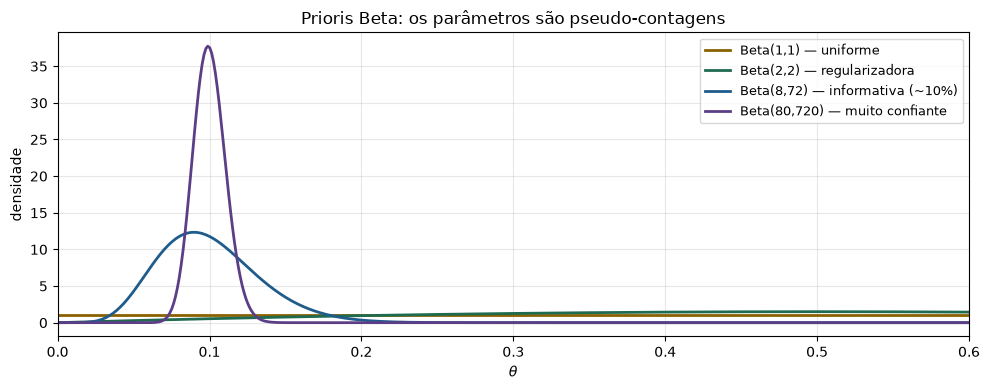

In [2]:
def descreve_beta(a, b, nome=""):
    d = stats.beta(a, b)
    ic = d.ppf([0.025, 0.975])
    print(f"{nome:<28s} Beta({a:>6.1f}, {b:>7.1f})  média={d.mean():.4f}  "
          f"dp={d.std():.4f}  IC95=[{ic[0]:.4f}, {ic[1]:.4f}]")
    return d


prioris = {
    "Beta(1,1) — uniforme": (1, 1),
    "Beta(2,2) — regularizadora": (2, 2),
    "Beta(8,72) — informativa (~10%)": (8, 72),
    "Beta(80,720) — muito confiante": (80, 720),
}

fig, ax = plt.subplots(figsize=(10, 4))
grade = np.linspace(0, 1, 800)
for (nome, (a, b)), cor in zip(prioris.items(), [AMBAR, VERDE, AZUL, ROXO]):
    ax.plot(grade, stats.beta.pdf(grade, a, b), lw=2, color=cor, label=nome)
    descreve_beta(a, b, nome)
ax.set_xlim(0, 0.6); ax.set_xlabel(r"$\theta$"); ax.set_ylabel("densidade")
ax.set_title("Prioris Beta: os parâmetros são pseudo-contagens")
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

## 2. Quanto a priori pesa, conforme os dados chegam

A mesma taxa de conversão real (14%), quatro prioris diferentes, cinco
tamanhos de amostra. Veja a priori perder importância.

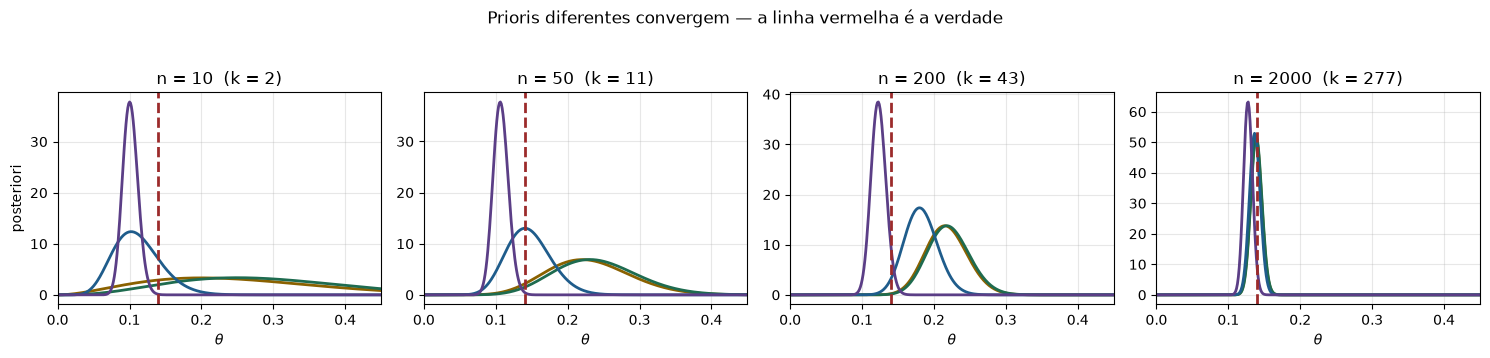

In [3]:
CONVERSAO_REAL = 0.14
TAMANHOS = [10, 50, 200, 2000]

fig, axes = plt.subplots(1, len(TAMANHOS), figsize=(15, 3.4), sharey=False)
for ax, n in zip(axes, TAMANHOS):
    k = rng.binomial(n, CONVERSAO_REAL)
    for (nome, (a, b)), cor in zip(prioris.items(), [AMBAR, VERDE, AZUL, ROXO]):
        ax.plot(grade, stats.beta.pdf(grade, a + k, b + n - k), lw=2, color=cor)
    ax.axvline(CONVERSAO_REAL, color=VERMELHO, lw=2, ls="--")
    ax.set_xlim(0, 0.45)
    ax.set_title(f"n = {n}  (k = {k})")
    ax.set_xlabel(r"$\theta$")
axes[0].set_ylabel("posteriori")
fig.suptitle("Prioris diferentes convergem — a linha vermelha é a verdade", y=1.04)
plt.tight_layout(); plt.show()

**A leitura:** com $n = 10$ as quatro posterioris são visivelmente diferentes —
a priori manda. Com $n = 2000$ elas se sobrepõem quase perfeitamente, e a
priori virou irrelevante.

> **O que isso resolve:** a objeção "bayesiano é subjetivo" vale exatamente
> onde há pouco dado — e ali a alternativa frequentista não é mais objetiva, é
> só menos explícita. Com 3 conversões em 12 visitas, a estimativa de máxima
> verossimilhança é 25%; ninguém acredita nisso, mas ela não declara por quê.

## 3. Atualização sequencial: um dado por vez

Uma propriedade que torna a conjugada perfeita para produção: processar os
dados **um a um** ou **todos de uma vez** dá exatamente o mesmo resultado.
Não é preciso guardar o histórico, só os dois parâmetros.

sequencial: Beta(57, 423)
em lote:    Beta(57, 423)   -> idênticos



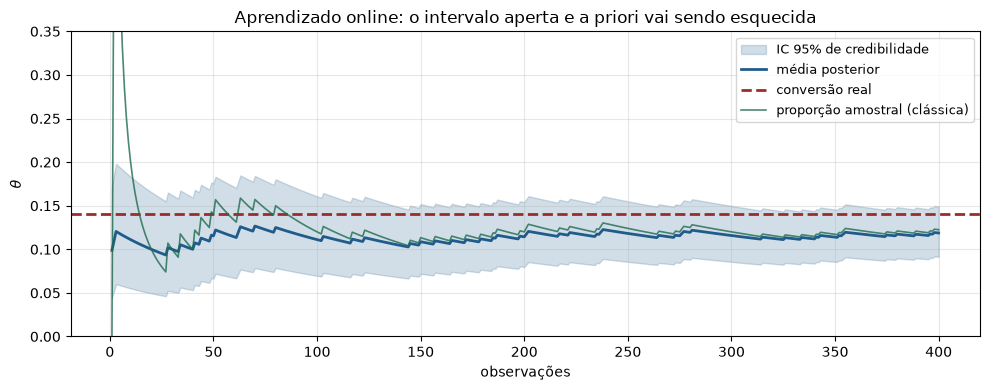

In [4]:
a0, b0 = 8, 72
observacoes = rng.random(400) < CONVERSAO_REAL

a, b = a0, b0
trajetoria = []
for i, sucesso in enumerate(observacoes, start=1):
    a += int(sucesso)
    b += int(not sucesso)
    d = stats.beta(a, b)
    trajetoria.append((i, d.mean(), *d.ppf([0.025, 0.975])))

traj = pd.DataFrame(trajetoria, columns=["n", "media", "inf", "sup"])

# em lote, de uma vez só
k_total = observacoes.sum()
a_lote, b_lote = a0 + k_total, b0 + len(observacoes) - k_total
print(f"sequencial: Beta({a}, {b})")
print(f"em lote:    Beta({a_lote}, {b_lote})   -> idênticos\n")

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(traj["n"], traj["inf"], traj["sup"], color=AZUL, alpha=0.2,
                label="IC 95% de credibilidade")
ax.plot(traj["n"], traj["media"], color=AZUL, lw=2, label="média posterior")
ax.axhline(CONVERSAO_REAL, color=VERMELHO, lw=2, ls="--", label="conversão real")
ax.plot(traj["n"], np.cumsum(observacoes) / traj["n"], color=VERDE, lw=1.2,
        alpha=0.8, label="proporção amostral (clássica)")
ax.set_ylim(0, 0.35); ax.set_xlabel("observações"); ax.set_ylabel(r"$\theta$")
ax.set_title("Aprendizado online: o intervalo aperta e a priori vai sendo esquecida")
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

Note o começo do gráfico: a linha verde (proporção amostral) salta
violentamente entre 0 e 0,5 nas primeiras dezenas de observações — é o
estimador clássico sendo inútil com pouco dado. A linha azul começa perto da
priori e desce suavemente. Esse amortecimento é **regularização**, e é o mesmo
mecanismo do Ridge.

## 4. A/B test bayesiano, do jeito que um time de produto usa

Duas variantes, duas posterioris. As perguntas de negócio viram contagens
sobre amostras da posteriori.

controle   : 561/4820 = 0.1164   posterior média 0.1161
tratamento : 623/4790 = 0.1301   posterior média 0.1296

P(B melhor que A)            = 0.9785
P(lift > 5%)                 = 0.8692
P(lift > 10%)                = 0.6031
lift mediano                 = +11.57%
IC 95% do lift               = [+0.34%, +24.06%]

perda esperada escolhendo B  = 0.000053 conversões/visita
perda esperada escolhendo A  = 0.013469 conversões/visita


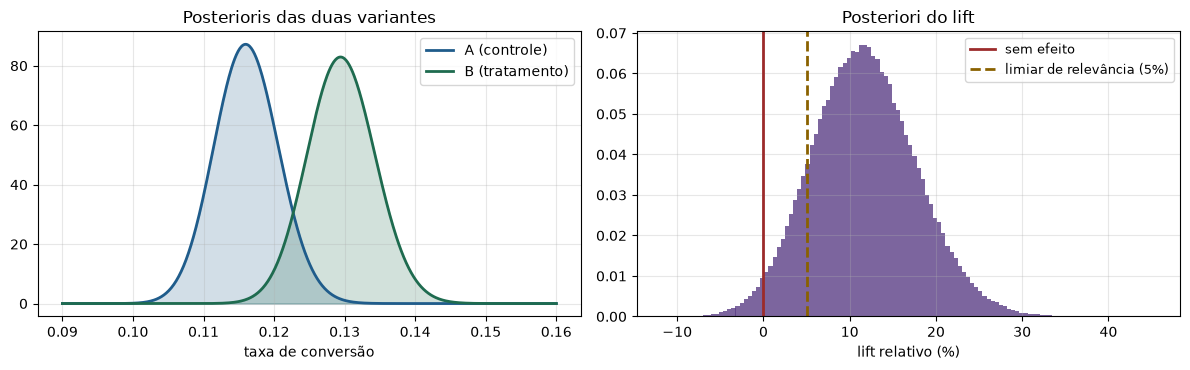

In [5]:
n_a, k_a = 4_820, 561     # controle
n_b, k_b = 4_790, 623     # tratamento
PRIORI_A, PRIORI_B = 8, 72

post_a = stats.beta(PRIORI_A + k_a, PRIORI_B + n_a - k_a)
post_b = stats.beta(PRIORI_A + k_b, PRIORI_B + n_b - k_b)

M = 300_000
amostras_a = post_a.rvs(M, random_state=1)
amostras_b = post_b.rvs(M, random_state=2)
lift = amostras_b / amostras_a - 1

print(f"controle   : {k_a}/{n_a} = {k_a/n_a:.4f}   posterior média {post_a.mean():.4f}")
print(f"tratamento : {k_b}/{n_b} = {k_b/n_b:.4f}   posterior média {post_b.mean():.4f}\n")
print(f"P(B melhor que A)            = {(amostras_b > amostras_a).mean():.4f}")
print(f"P(lift > 5%)                 = {(lift > 0.05).mean():.4f}")
print(f"P(lift > 10%)                = {(lift > 0.10).mean():.4f}")
print(f"lift mediano                 = {np.median(lift):+.2%}")
print(f"IC 95% do lift               = [{np.percentile(lift, 2.5):+.2%}, "
      f"{np.percentile(lift, 97.5):+.2%}]")

# perda esperada: quanto se perde, em conversão, ao escolher errado
perda_se_escolher_b = np.maximum(amostras_a - amostras_b, 0).mean()
perda_se_escolher_a = np.maximum(amostras_b - amostras_a, 0).mean()
print(f"\nperda esperada escolhendo B  = {perda_se_escolher_b:.6f} conversões/visita")
print(f"perda esperada escolhendo A  = {perda_se_escolher_a:.6f} conversões/visita")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
g = np.linspace(0.09, 0.16, 600)
axes[0].plot(g, post_a.pdf(g), color=AZUL, lw=2, label="A (controle)")
axes[0].plot(g, post_b.pdf(g), color=VERDE, lw=2, label="B (tratamento)")
axes[0].fill_between(g, post_a.pdf(g), color=AZUL, alpha=0.2)
axes[0].fill_between(g, post_b.pdf(g), color=VERDE, alpha=0.2)
axes[0].set_xlabel("taxa de conversão"); axes[0].set_title("Posterioris das duas variantes")
axes[0].legend()

axes[1].hist(lift * 100, bins=120, color=ROXO, alpha=0.8, density=True)
axes[1].axvline(0, color=VERMELHO, lw=2, label="sem efeito")
axes[1].axvline(5, color=AMBAR, lw=2, ls="--", label="limiar de relevância (5%)")
axes[1].set_xlabel("lift relativo (%)"); axes[1].set_title("Posteriori do lift")
axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

**A regra de decisão que times usam na prática:** implante quando a **perda
esperada** de fazê-lo cair abaixo de um limiar de tolerância (por exemplo,
0,0002 conversões por visita). Isso é diferente de "esperar dar significativo":
a decisão é tomada quando o **custo esperado do erro** é aceitável, não quando
uma estatística cruza uma linha arbitrária.

> **E o problema de espiar?** Não existe aqui. A posteriori é válida a qualquer
> momento, porque não há taxa de erro de longo prazo sendo controlada — a
> pergunta mudou. O que continua existindo é o risco de decidir cedo demais com
> pouca informação, e a perda esperada é exatamente a métrica que protege disso.

## 5. Gama-Poisson: contagens

Para contagens (chamados por dia, falhas por mês, cliques por sessão), a
conjugada é Gama-Poisson:

$$\text{Gama}(\alpha, \beta) + \text{dados} \;\Rightarrow\;
\text{Gama}\left(\alpha + \sum x_i,\; \beta + n\right)$$

Aqui $\alpha$ é "eventos já vistos" e $\beta$ é "períodos já observados".

chamados observados: [20 26 20 24 13 15 24 22 22 26 26 16 23 25]

priori    : média 18.00  IC95 [10.7, 27.2]
posteriori: média 21.33  IC95 [19.1, 23.7]
média amostral (clássica): 21.57

P(mais de 30 chamados amanhã) = 0.0339
percentil 95 da previsão      = 30 chamados
(dimensione o plantão por esse número, não pela média)


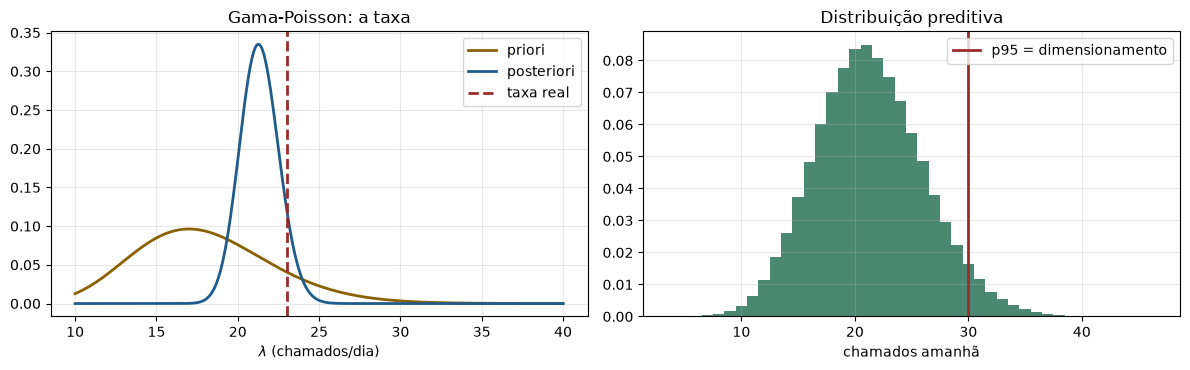

In [6]:
# priori: histórico sugere ~18 chamados/dia, com boa incerteza
alfa0, beta0 = 18, 1        # equivale a "vi 18 chamados em 1 dia"
chamados = rng.poisson(23, size=14)   # a taxa real mudou para 23

print("chamados observados:", chamados)

alfa_post, beta_post = alfa0 + chamados.sum(), beta0 + len(chamados)
post_lambda = stats.gamma(a=alfa_post, scale=1 / beta_post)
priori_lambda = stats.gamma(a=alfa0, scale=1 / beta0)

print(f"\npriori    : média {priori_lambda.mean():.2f}  IC95 "
      f"[{priori_lambda.ppf(0.025):.1f}, {priori_lambda.ppf(0.975):.1f}]")
print(f"posteriori: média {post_lambda.mean():.2f}  IC95 "
      f"[{post_lambda.ppf(0.025):.1f}, {post_lambda.ppf(0.975):.1f}]")
print(f"média amostral (clássica): {chamados.mean():.2f}")

# previsão para amanhã: distribuição PREDITIVA, não só a média
amostras_lambda = post_lambda.rvs(200_000, random_state=5)
preditiva = rng.poisson(amostras_lambda)
print(f"\nP(mais de 30 chamados amanhã) = {(preditiva > 30).mean():.4f}")
print(f"percentil 95 da previsão      = {np.percentile(preditiva, 95):.0f} chamados")
print("(dimensione o plantão por esse número, não pela média)")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
g = np.linspace(10, 40, 500)
axes[0].plot(g, priori_lambda.pdf(g), color=AMBAR, lw=2, label="priori")
axes[0].plot(g, post_lambda.pdf(g), color=AZUL, lw=2, label="posteriori")
axes[0].axvline(23, color=VERMELHO, lw=2, ls="--", label="taxa real")
axes[0].set_xlabel(r"$\lambda$ (chamados/dia)"); axes[0].legend()
axes[0].set_title("Gama-Poisson: a taxa")

axes[1].hist(preditiva, bins=np.arange(preditiva.min(), preditiva.max() + 1) - 0.5,
             color=VERDE, alpha=0.8, density=True)
axes[1].axvline(np.percentile(preditiva, 95), color=VERMELHO, lw=2,
                label="p95 = dimensionamento")
axes[1].set_xlabel("chamados amanhã"); axes[1].set_title("Distribuição preditiva")
axes[1].legend()
plt.tight_layout(); plt.show()

**A distribuição preditiva é o entregável.** A posteriori de $\lambda$ é
incerteza sobre o *parâmetro*; a preditiva soma a isso a variabilidade
*intrínseca* do Poisson. Dimensionar equipe pela média de $\lambda$ ignora
metade da incerteza — e é assim que se monta um plantão que estoura toda
terça-feira.

## 6. Normal-Normal: por que Ridge é uma priori

Com variância conhecida, a média posterior é uma **média ponderada pelas
precisões**:

$$\mu_{\text{post}} = \frac{\frac{1}{\tau_0^2}\mu_0 + \frac{n}{\sigma^2}\bar{x}}
{\frac{1}{\tau_0^2} + \frac{n}{\sigma^2}}$$

In [7]:
def normal_normal(mu0, tau0, x, sigma):
    n = len(x)
    prec_priori, prec_dados = 1 / tau0**2, n / sigma**2
    mu_post = (prec_priori * mu0 + prec_dados * x.mean()) / (prec_priori + prec_dados)
    tau_post = np.sqrt(1 / (prec_priori + prec_dados))
    peso_dados = prec_dados / (prec_priori + prec_dados)
    return mu_post, tau_post, peso_dados


SIGMA = 12
dados = rng.normal(105, SIGMA, size=8)

print(f"{'priori':<26s} {'n':>4s} {'média post.':>12s} {'dp post.':>10s} {'peso dados':>12s}")
print("-" * 68)
for nome, (mu0, tau0) in {"vaga  N(100, 30)": (100, 30),
                          "moderada N(100, 8)": (100, 8),
                          "forte N(100, 2)": (100, 2)}.items():
    mp, tp, peso = normal_normal(mu0, tau0, dados, SIGMA)
    print(f"{nome:<26s} {len(dados):>4d} {mp:>12.3f} {tp:>10.3f} {peso:>11.1%}")
print(f"\nmédia amostral pura: {dados.mean():.3f}")

priori                        n  média post.   dp post.   peso dados
--------------------------------------------------------------------
vaga  N(100, 30)              8      112.801      4.201       98.0%
moderada N(100, 8)            8      110.191      3.748       78.0%
forte N(100, 2)               8      102.374      1.809       18.2%

média amostral pura: 113.057


**A conexão com regularização, explicitamente:** maximizar a log-posteriori de
um modelo linear com priori normal $\mathcal{N}(0, \tau^2)$ sobre os
coeficientes dá

$$\arg\min_\beta \; \|y - X\beta\|^2 + \frac{\sigma^2}{\tau^2}\|\beta\|^2$$

que é **exatamente** a regressão Ridge com $\lambda = \sigma^2/\tau^2$. Priori
normal ⇒ penalidade L2 (Ridge). Priori de Laplace ⇒ penalidade L1 (Lasso).

Isso significa que todo modelo regularizado que você já treinou era um estimador
MAP bayesiano — só que sem ninguém dizer qual priori estava sendo assumida.
Escolher $\lambda$ por validação cruzada é escolher a priori pelos dados.

## O que levar deste notebook

- **Conjugada = somar contagens.** Beta-Binomial cobre proporções;
  Gama-Poisson cobre contagens; Normal-Normal cobre médias.
- Os hiperparâmetros da priori são **pseudo-observações** — declaráveis e
  auditáveis.
- **Atualização sequencial é gratuita** e idêntica ao processamento em lote.
- Em A/B testing, a posteriori entrega **P(B > A)**, **lift com intervalo** e
  **perda esperada** — as três coisas que a reunião pede.
- Para previsão, use a **distribuição preditiva**, não a média da posteriori.
- **Ridge e Lasso são MAP com priori normal e de Laplace.**

→ No próximo notebook: o que fazer quando não existe conjugada — **MCMC do
zero**.